# 02 — Energy crossing, equal-energy preparations, and preparation tolerance

Companion to the deterministic inversion and preparation-geometry discussion. It keeps the analytical crossing result visible, expands the equal-energy geometry, and makes preparation-error scaling executable.


## Guiding question
How can two monotone energy curves reverse their ordering, and why can equal-energy preparations relax differently?


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, solve_continuous_lyapunov
np.set_printoptions(precision=6, suppress=True)


## 1. Pure-mode crossing
For pure slow/fast preparations,
$$
E_s(t)=E_s(0)e^{2\lambda_st},\qquad
E_f(t)=E_f(0)e^{2\lambda_ft}.
$$
If $E_f(0)>E_s(0)$ and $\lambda_f<\lambda_s<0$,
$$
t_\times=\frac{\ln[E_s(0)/E_f(0)]}{2(\lambda_f-\lambda_s)}.
$$


In [2]:
ls=-100.; lf=-1000.; Es0=1e-6; Ef0=10e-6
tx=np.log(Es0/Ef0)/(2*(lf-ls))
Ex=Es0*np.exp(2*ls*tx)
print('reference crossing [ms] =',1e3*tx,' energy [uJ] =',1e6*Ex)
assert np.isclose(tx,1.27921394e-3,rtol=1e-5)


reference crossing [ms] = 1.2792139405522478  energy [uJ] = 0.774263682681127


## 2. Equal-energy ellipse
At fixed $E_0$,
$$
q_0(\theta)=\sqrt{2CE_0}\cos\theta,\qquad
I_0(\theta)=\sqrt{2E_0/L}\sin\theta.
$$
Every point has the same energy but generally different slow/fast modal coefficients.


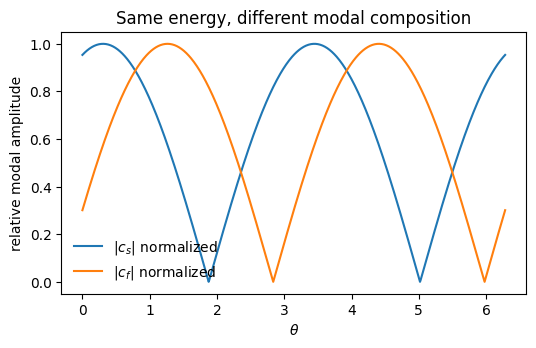

In [3]:
L=0.100; C=100e-6; R=110.
disc=(R/L)**2-4/(L*C)
ls=(-R/L+np.sqrt(disc))/2; lf=(-R/L-np.sqrt(disc))/2
E0=5e-6
theta=np.linspace(0,2*np.pi,721)
q=np.sqrt(2*C*E0)*np.cos(theta)
I=np.sqrt(2*E0/L)*np.sin(theta)
cs=(I-lf*q)/(ls-lf); cf=(ls*q-I)/(ls-lf)
E=0.5*q*q/C+0.5*L*I*I
assert np.allclose(E,E0)
fig,ax=plt.subplots(figsize=(6,3.4))
ax.plot(theta, np.abs(cs)/np.max(np.abs(cs)), label=r'$|c_s|$ normalized')
ax.plot(theta, np.abs(cf)/np.max(np.abs(cf)), label=r'$|c_f|$ normalized')
ax.set(xlabel=r'$\theta$',ylabel='relative modal amplitude',title='Same energy, different modal composition')
ax.legend(frameon=False); plt.show()


## 3. Preparation error near the fast eigendirection
If the intended fast preparation has
$$
I_0=\lambda_fq_0+\delta I,
$$
then
$$
c_s=\frac{\delta I}{\lambda_s-\lambda_f}.
$$
The slow **amplitude** is linear in the current error, while the asymptotic slow-mode energy is quadratic in that error.


In [4]:
q0=1e-5
errs=np.logspace(-7,-3,20)*abs(lf*q0)
slow_amp=[]; slow_energy=[]
G=np.diag([1/C,L]); rs=np.array([1.,ls])
for dI in errs:
    cslow=dI/(ls-lf)
    slow_amp.append(abs(cslow))
    slow_energy.append(0.5*cslow**2*(rs@G@rs))
pa=np.polyfit(np.log(errs),np.log(slow_amp),1)[0]
pe=np.polyfit(np.log(errs),np.log(slow_energy),1)[0]
print('log-log slopes: amplitude',pa,'energy',pe)
assert abs(pa-1)<1e-10 and abs(pe-2)<1e-10


log-log slopes: amplitude 1.0000000000000007 energy 2.0000000000000013


## Reader exploration
Choose a measurement floor and determine the maximum preparation error that keeps the residual slow tail below that floor over the chosen record length.
